# I extracted the shot data from sofascore

In [10]:
from curl_cffi import requests
from bs4 import BeautifulSoup

url = "https://www.sofascore.com/api/v1/event/14435482/shotmap"

response = requests.get(url)
response.status_code
response.json()

print(response.status_code)
print(response.json())

data = response.json()
print(data.keys())

200
{'shotmap': [{'player': {'name': 'Pauline Machtens', 'slug': 'pauline-machtens', 'shortName': 'P. Machtens', 'position': 'M', 'jerseyNumber': '28', 'userCount': 17, 'gender': 'F', 'id': 1009100, 'fieldTranslations': {'nameTranslation': {'ar': 'بولين ماختنس'}, 'shortNameTranslation': {'ar': 'ب. ماختنس'}}}, 'isHome': True, 'shotType': 'save', 'situation': 'regular', 'playerCoordinates': {'x': 20.6, 'y': 46.6, 'z': 0}, 'bodyPart': 'right-foot', 'goalMouthLocation': 'low-left', 'goalMouthCoordinates': {'x': 0, 'y': 53.9, 'z': 10.8}, 'blockCoordinates': {'x': 1.2, 'y': 49.8, 'z': 0}, 'goalkeeper': {'name': 'Rafaela Borggräfe', 'slug': 'rafaela-borggrafe', 'shortName': 'R. Borggräfe', 'position': 'G', 'jerseyNumber': '12', 'userCount': 119, 'gender': 'F', 'id': 1009236, 'fieldTranslations': {'nameTranslation': {'ar': 'رافائيلا بورغرايف'}, 'shortNameTranslation': {'ar': 'ر. بورغرايف'}}}, 'id': 6977704, 'time': 90, 'addedTime': 5, 'timeSeconds': 5647, 'draw': {'start': {'x': 46.6, 'y': 20.

# I converted it into a DataFrame

In [11]:
import pandas as pd

shots = pd.DataFrame(data["shotmap"])

print(shots.head())

                                              player  isHome shotType  \
0  {'name': 'Pauline Machtens', 'slug': 'pauline-...    True     save   
1  {'name': 'Melanie Brunnthaler', 'firstName': '...    True    block   
2  {'name': 'Mária Mikolajová', 'firstName': 'Már...    True     miss   
3  {'name': 'Mária Mikolajová', 'firstName': 'Már...    True     miss   
4  {'name': 'Mária Mikolajová', 'firstName': 'Már...    True     miss   

  situation               playerCoordinates    bodyPart goalMouthLocation  \
0   regular  {'x': 20.6, 'y': 46.6, 'z': 0}  right-foot          low-left   
1  assisted  {'x': 14.5, 'y': 46.7, 'z': 0}   left-foot        low-centre   
2    corner  {'x': 11.1, 'y': 67.3, 'z': 0}   left-foot              high   
3    corner  {'x': 21.3, 'y': 61.2, 'z': 0}   left-foot         high-left   
4    corner    {'x': 17, 'y': 65.2, 'z': 0}  right-foot              left   

             goalMouthCoordinates               blockCoordinates  \
0  {'x': 0, 'y': 53.9, 'z': 10

In [12]:
import pandas as pd

shots_df = pd.DataFrame({
    "player": [s["player"]["name"] for s in data["shotmap"]],
    "team_home": [s["isHome"] for s in data["shotmap"]],
    "shot_type": [s["shotType"] for s in data["shotmap"]],
    "situation": [s["situation"] for s in data["shotmap"]],
    "body_part": [s["bodyPart"] for s in data["shotmap"]],
    "x": [s["playerCoordinates"]["x"] for s in data["shotmap"]],
    "y": [s["playerCoordinates"]["y"] for s in data["shotmap"]],
    "xg": [s.get("xg", 0) for s in data["shotmap"]],  # Use 0 if xG is missing
    "minute": [s["time"] for s in data["shotmap"]]
})

print(shots_df.head())

                player  team_home shot_type situation   body_part     x     y  \
0     Pauline Machtens       True      save   regular  right-foot  20.6  46.6   
1  Melanie Brunnthaler       True     block  assisted   left-foot  14.5  46.7   
2     Mária Mikolajová       True      miss    corner   left-foot  11.1  67.3   
3     Mária Mikolajová       True      miss    corner   left-foot  21.3  61.2   
4     Mária Mikolajová       True      miss    corner  right-foot  17.0  65.2   

   xg  minute  
0   0      90  
1   0      90  
2   0      90  
3   0      90  
4   0      90  


In [13]:
shots_df.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Pauline Machtens,True,save,regular,right-foot,20.6,46.6,0,90
1,Melanie Brunnthaler,True,block,assisted,left-foot,14.5,46.7,0,90
2,Mária Mikolajová,True,miss,corner,left-foot,11.1,67.3,0,90
3,Mária Mikolajová,True,miss,corner,left-foot,21.3,61.2,0,90
4,Mária Mikolajová,True,miss,corner,right-foot,17.0,65.2,0,90


In [72]:
shots_df.to_csv("shots4.csv", index=False)
from google.colab import files
files.download("shots4.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
shots_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player            36 non-null     object 
 1   team_home         36 non-null     bool   
 2   shot_type         36 non-null     object 
 3   situation         36 non-null     object 
 4   body_part         36 non-null     object 
 5   x                 36 non-null     float64
 6   y                 36 non-null     float64
 7   xg                36 non-null     int64  
 8   minute            36 non-null     int64  
 9   distance_to_goal  36 non-null     float64
 10  count             36 non-null     int64  
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 3.0+ KB


In [14]:
shots_df.player.value_counts()

,count
player,
Cornelia Kramer,5
Loreen Bender,4
Katharina Piljić,4
Vanessa Fudalla,4
Mária Mikolajová,3
Ruby Grant,3
Julia Mickenhagen,2
Juliette Vidal,2
Sofie Zdebel,2


# Basic Match Summary

In [15]:
shots_df.groupby('team_home')['shot_type'].count()

,shot_type
team_home,
False,27
True,9


In [16]:
shots_df.groupby(['team_home', 'shot_type']).size().unstack(fill_value=0)

shot_type,block,goal,miss,post,save
team_home,,,,,
False,6,3,10,1,7
True,3,1,4,0,1


# shots efficiency

In [18]:
import pandas as pd

# Sample data
data = {
    'team_home': [False, True],
    'block': [6, 3],
    'goal': [3, 1],
    'miss': [10, 4],
    'post': [1, 0],
    'save': [7, 1]
}

df = pd.DataFrame(data)
df.set_index('team_home', inplace=True)

# Calculate total shots
df['total_shots'] = df.sum(axis=1)

# Calculate shots on target (goals + saves)
df['shots_on_target'] = df['goal'] + df['save']

# Shooting accuracy %
df['shooting_accuracy'] = (df['shots_on_target'] / df['total_shots'] * 100).round(2)

print(df[['total_shots', 'shots_on_target', 'shooting_accuracy']])

           total_shots  shots_on_target  shooting_accuracy
team_home                                                 
False               27               10              37.04
True                 9                2              22.22


# Average Shot Distance

In [17]:
shots_df.groupby('team_home')[['x','y']].mean()

,x,y
team_home,,
False,12.844444,49.588889
True,16.111111,52.888889


# Average distance to goal

In [23]:
import numpy as np

# Assuming goal is at x=100, y=50
shots_df['distance_to_goal'] = np.sqrt((shots_df['x'])**2 + (shots_df['y'] - 50)**2)

shots_df.groupby('team_home')['distance_to_goal'].mean()

,distance_to_goal
team_home,
False,15.885249
True,20.034007


# Total shots per player

In [24]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

                 player  Total_Shots
0       Camilla Linberg            1
1       Cornelia Kramer            5
2           Jonna Wrede            1
3     Julia Mickenhagen            2
4        Juliette Vidal            2
5      Katharina Piljić            4
6         Kristin Kögel            1
7         Loreen Bender            4
8   Melanie Brunnthaler            1
9         Melina Krüger            1
10     Mária Mikolajová            3
11     Pauline Machtens            1
12           Ruby Grant            3
13         Sofie Zdebel            2
14          Svea Stoldt            1
15      Vanessa Fudalla            4


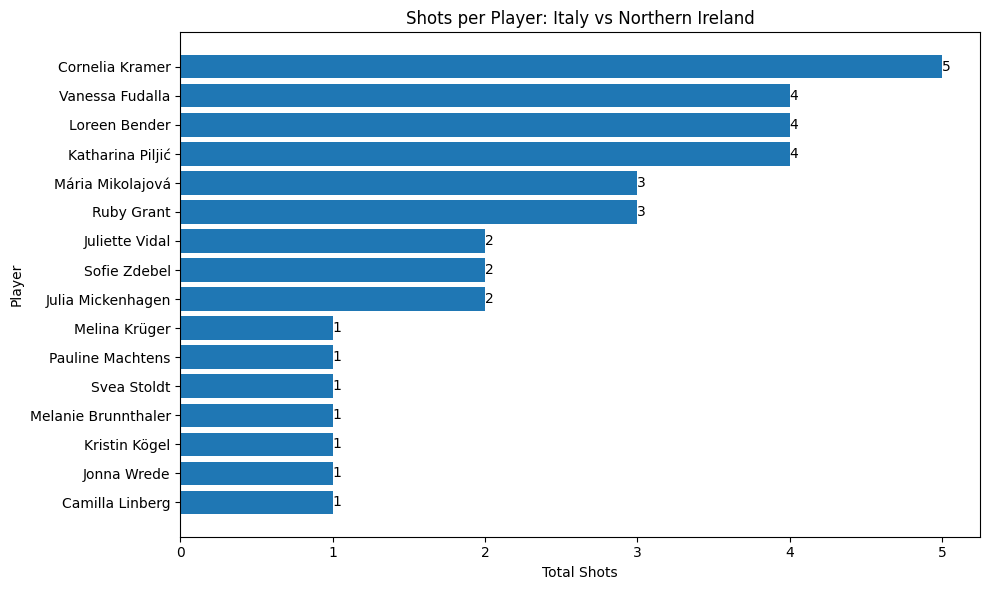

In [32]:
import pandas as pd

data = {
    "player": [
        "Camilla Linberg", "Cornelia Kramer", "Jonna Wrede",
        "Julia Mickenhagen", "Juliette Vidal", "Katharina Piljić",
        "Kristin Kögel", "Loreen Bender", "Melanie Brunnthaler",
        "Melina Krüger", "Mária Mikolajová", "Pauline Machtens",
        "Ruby Grant", "Sofie Zdebel", "Svea Stoldt", "Vanessa Fudalla"
    ],
    "Total_Shots": [1, 5, 1, 2, 2, 4, 1, 4, 1, 1, 3, 1, 3, 2, 1, 4]
}

df_players = pd.DataFrame(data)

df = pd.DataFrame(data)

# Sort by shots (important for clean visualization)
df = df.sort_values(by="Total_Shots", ascending=True)

# Plot
plt.figure(figsize=(10,6))
plt.barh(df["player"], df["Total_Shots"])

# Labels & title
plt.xlabel("Total Shots")
plt.ylabel("Player")
plt.title("Shots per Player: Italy vs Northern Ireland")

# Show values on bars
for index, value in enumerate(df["Total_Shots"]):
    plt.text(value, index, str(value), va='center')

plt.tight_layout()
plt.show()

# Separate the teams

In [28]:
home_shots = shots_df[shots_df["team_home"] == True]
away_shots = shots_df[shots_df["team_home"] == False]

# Number of situation by player

In [30]:
shots_df.groupby("player")["situation"].value_counts()

player               situation 
Camilla Linberg      fast-break    1
Cornelia Kramer      assisted      4
                     fast-break    1
Jonna Wrede          assisted      1
Julia Mickenhagen    assisted      1
                     corner        1
Juliette Vidal       assisted      1
                     corner        1
Katharina Piljić     assisted      2
                     corner        1
                     regular       1
Kristin Kögel        assisted      1
Loreen Bender        assisted      2
                     corner        1
                     regular       1
Melanie Brunnthaler  assisted      1
Melina Krüger        regular       1
Mária Mikolajová     corner        3
Pauline Machtens     regular       1
Ruby Grant           assisted      1
                     corner        1
                     regular       1
Sofie Zdebel         corner        1
                     regular       1
Svea Stoldt          set-piece     1
Vanessa Fudalla      assisted      2
                     corner        1
                     regular       1
Name: count, dtype: int64

# Number of situation by Team

In [41]:
situation_counts= shots_df.groupby("team_home")["situation"].value_counts()
print(situation_counts)

team_home  situation 
False      assisted      14
           corner         7
           regular        5
           fast-break     1
True       corner         3
           assisted       2
           regular        2
           fast-break     1
           set-piece      1
Name: count, dtype: int64


# number of situation by team, player distance and location

In [39]:
situation_counts= shots_df.groupby(["team_home", "player", "x","y"])["situation"].value_counts().reset_index(name="shots")
print(situation_counts)

    team_home               player     x     y   situation  shots
0       False      Cornelia Kramer   3.6  50.3    assisted      1
1       False      Cornelia Kramer   7.0  48.5    assisted      1
2       False      Cornelia Kramer   8.6  69.5    assisted      1
3       False      Cornelia Kramer  10.6  58.4  fast-break      1
4       False      Cornelia Kramer  12.1  44.3    assisted      1
5       False    Julia Mickenhagen   8.1  37.3    assisted      1
6       False    Julia Mickenhagen  18.1  45.4      corner      1
7       False       Juliette Vidal   4.1  45.2      corner      1
8       False       Juliette Vidal  18.9  38.5    assisted      1
9       False     Katharina Piljić   8.5  43.4    assisted      1
10      False     Katharina Piljić  12.7  38.5     regular      1
11      False     Katharina Piljić  13.7  66.1      corner      1
12      False     Katharina Piljić  27.1  42.6    assisted      1
13      False        Kristin Kögel   3.9  43.8    assisted      1
14      Fa

# shot type per team, player and situation

In [42]:
shot_type_counts = shots_df.groupby(["team_home","player", "situation"])["shot_type"].value_counts()
print(shot_type_counts)

team_home  player               situation   shot_type
False      Cornelia Kramer      assisted    miss         2
                                            post         1
                                            save         1
                                fast-break  miss         1
           Julia Mickenhagen    assisted    goal         1
                                corner      block        1
           Juliette Vidal       assisted    save         1
                                corner      save         1
           Katharina Piljić     assisted    goal         1
                                            save         1
                                corner      miss         1
                                regular     miss         1
           Kristin Kögel        assisted    save         1
           Loreen Bender        assisted    miss         2
                                corner      save         1
                                regular     miss         1
  

# Goals per player

In [46]:
df_goals = df_detail[df_detail['shot_type'] == 'goal'] \
    .groupby('player')['count'].sum().reset_index()
print(df_goals)

              player  count
0    Camilla Linberg      1
1  Julia Mickenhagen      1
2   Katharina Piljić      1
3    Vanessa Fudalla      1


# Shooting accuracy per player

In [49]:
df_on_target = df_detail[df_detail['shot_type'].isin(['goal','save'])] \
    .groupby('player')['count'].sum()

df_total = df_detail.groupby('player')['count'].sum()

df_accuracy = (df_on_target / df_total).fillna(0).reset_index(name='accuracy')
print(df_accuracy)

                 player  accuracy
0       Camilla Linberg  1.000000
1       Cornelia Kramer  0.200000
2           Jonna Wrede  0.000000
3     Julia Mickenhagen  0.500000
4        Juliette Vidal  1.000000
5      Katharina Piljić  0.500000
6         Kristin Kögel  1.000000
7         Loreen Bender  0.250000
8   Melanie Brunnthaler  0.000000
9         Melina Krüger  0.000000
10     Mária Mikolajová  0.000000
11     Pauline Machtens  1.000000
12           Ruby Grant  0.333333
13         Sofie Zdebel  0.000000
14          Svea Stoldt  0.000000
15      Vanessa Fudalla  0.250000


# shots outcome by Team

In [51]:
df_team = df_detail.groupby(['team_home','shot_type'])['count'].sum().reset_index()
print(df_team)

   team_home shot_type  count
0      False     block      6
1      False      goal      3
2      False      miss     10
3      False      post      1
4      False      save      7
5       True     block      3
6       True      goal      1
7       True      miss      4
8       True      save      1


# Top players Performance Table

In [55]:
import pandas as pd
import numpy as np

# 1️⃣ Total shots per player
df_total_shots = df_detail.groupby('player')['count'].sum().reset_index(name='total_shots')

# 2️⃣ Goals per player
df_goals = df_detail[df_detail['shot_type'] == 'goal'] \
    .groupby('player')['count'].sum().reset_index(name='goals')

# 3️⃣ Average distance to goal per player
shots_df['distance_to_goal'] = np.sqrt(shots_df['x']**2 + (shots_df['y'] - 50)**2)
df_avg_distance = shots_df.groupby('player')['distance_to_goal'].mean().reset_index(name='avg_distance')

# 4️⃣ Merge everything together
df_top_players = df_total_shots.merge(df_goals, on='player', how='left') \
                                .merge(df_accuracy.rename(columns={'accuracy':'shooting_accuracy'}), on='player', how='left') \
                                .merge(df_avg_distance, on='player', how='left')

# Fill NaN goals with 0
df_top_players['goals'] = df_top_players['goals'].fillna(0)

# Sort by goals first, then accuracy, then total shots
df_top_players = df_top_players.sort_values(by=['goals','shooting_accuracy','total_shots'], ascending=[False,False,False]).reset_index(drop=True)

df_top_players

,player,total_shots,goals,shooting_accuracy,avg_distance
0,Camilla Linberg,1,1.0,1.000000,12.647925
1,Katharina Piljić,4,1.0,0.500000,19.281673
2,Julia Mickenhagen,2,1.0,0.500000,16.869293
3,Vanessa Fudalla,4,1.0,0.250000,18.891044
4,Juliette Vidal,2,0.0,1.000000,14.218214
5,Kristin Kögel,1,0.0,1.000000,7.324616
6,Pauline Machtens,1,0.0,1.000000,20.878697
7,Ruby Grant,3,0.0,0.333333,18.116548
8,Loreen Bender,4,0.0,0.250000,11.894022
9,Cornelia Kramer,5,0.0,0.200000,11.796747


# Shots by body part

In [56]:
shots_df["body_part"].value_counts()

,count
body_part,
right-foot,18
left-foot,14
head,4


# Shots by body part, player and shot outcome

In [57]:
shot_type_counts = shots_df.groupby(["player","shot_type"])["body_part"].value_counts()
print(shot_type_counts)

player               shot_type  body_part 
Camilla Linberg      goal       right-foot    1
Cornelia Kramer      miss       head          1
                                left-foot     1
                                right-foot    1
                     post       right-foot    1
                     save       right-foot    1
Jonna Wrede          block      right-foot    1
Julia Mickenhagen    block      right-foot    1
                     goal       left-foot     1
Juliette Vidal       save       left-foot     2
Katharina Piljić     goal       right-foot    1
                     miss       left-foot     2
                     save       left-foot     1
Kristin Kögel        save       head          1
Loreen Bender        miss       right-foot    2
                                left-foot     1
                     save       head          1
Melanie Brunnthaler  block      left-foot     1
Melina Krüger        miss       right-foot    1
Mária Mikolajová     miss       left-foot    

# Goals by body part

In [60]:
if 'count' not in shots_df.columns:
    shots_df['count'] = 1

In [61]:
df_goals = shots_df[shots_df['shot_type']=='goal'] \
    .groupby('body_part')['count'].sum().reset_index()

print(df_goals)

    body_part  count
0   left-foot      1
1  right-foot      3


In [66]:
# Correct way to group by multiple columns and count shot_type
shot_type_counts = shots_df.groupby(["team_home","player", "x", "y"])["shot_type"].value_counts().reset_index(name='count')

print(shot_type_counts)

    team_home               player     x     y shot_type  count
0       False      Cornelia Kramer   3.6  50.3      miss      1
1       False      Cornelia Kramer   7.0  48.5      miss      1
2       False      Cornelia Kramer   8.6  69.5      save      1
3       False      Cornelia Kramer  10.6  58.4      miss      1
4       False      Cornelia Kramer  12.1  44.3      post      1
5       False    Julia Mickenhagen   8.1  37.3      goal      1
6       False    Julia Mickenhagen  18.1  45.4     block      1
7       False       Juliette Vidal   4.1  45.2      save      1
8       False       Juliette Vidal  18.9  38.5      save      1
9       False     Katharina Piljić   8.5  43.4      goal      1
10      False     Katharina Piljić  12.7  38.5      miss      1
11      False     Katharina Piljić  13.7  66.1      miss      1
12      False     Katharina Piljić  27.1  42.6      save      1
13      False        Kristin Kögel   3.9  43.8      save      1
14      False        Loreen Bender   5.8

# Shots Map

In [62]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 7.3 MB/s eta 0:00:00


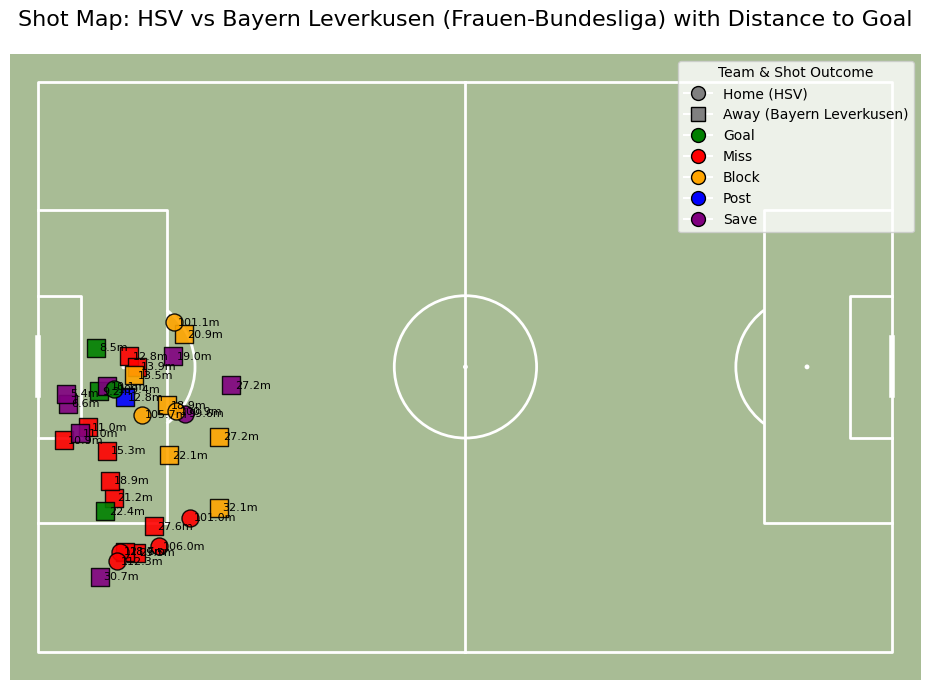

In [67]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Match shot data
data = {
    "team_home": [False]*27 + [True]*9,
    "player": [
        "Cornelia Kramer","Cornelia Kramer","Cornelia Kramer","Cornelia Kramer","Cornelia Kramer",
        "Julia Mickenhagen","Julia Mickenhagen","Juliette Vidal","Juliette Vidal",
        "Katharina Piljić","Katharina Piljić","Katharina Piljić","Katharina Piljić",
        "Kristin Kögel","Loreen Bender","Loreen Bender","Loreen Bender","Loreen Bender",
        "Ruby Grant","Ruby Grant","Ruby Grant","Sofie Zdebel","Sofie Zdebel",
        "Vanessa Fudalla","Vanessa Fudalla","Vanessa Fudalla","Vanessa Fudalla",
        "Camilla Linberg","Jonna Wrede","Melanie Brunnthaler","Melina Krüger",
        "Mária Mikolajová","Mária Mikolajová","Mária Mikolajová","Pauline Machtens","Svea Stoldt"
    ],
    "x": [
        3.6,7.0,8.6,10.6,12.1,8.1,18.1,4.1,18.9,8.5,12.7,13.7,27.1,3.9,5.8,9.7,10.1,12.2,
        9.7,13.9,20.4,16.2,25.4,9.4,13.4,18.3,25.3,10.6,19.1,14.5,11.5,11.1,17.0,21.3,20.6,19.3
    ],
    "y": [
        50.3,48.5,69.5,58.4,44.3,37.3,45.4,45.2,38.5,43.4,38.5,66.1,42.6,43.8,49.3,51.8,56.0,66.0,
        42.7,40.0,35.4,62.4,49.8,60.3,41.2,52.4,59.8,43.1,33.7,46.7,66.0,67.3,65.2,61.2,46.6,46.2
    ],
    "shot_type": [
        "miss","miss","save","miss","post","goal","block","save","save",
        "goal","miss","miss","save","save","save","miss","miss","miss",
        "save","miss","block","miss","block","goal","block","block","block",
        "goal","block","block","miss","miss","miss","miss","save","block"
    ],
    "count":[1]*36
}

df = pd.DataFrame(data)

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Color map for shot outcomes
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'post':'blue', 'save':'purple'}

# Function to calculate distance to goal
def distance_to_goal(x, y, home=True):
    if home:
        return np.round(np.sqrt((120 - x)**2 + (40 - y)**2),1)  # Home attacks right
    else:
        return np.round(np.sqrt((0 - x)**2 + (40 - y)**2),1)    # Away attacks left

# Plot shots
for idx, row in df.iterrows():
    home = row['team_home']
    dist = distance_to_goal(row['x'], row['y'], home)
    ax.scatter(row['x'], row['y'],
               color=shot_colors[row['shot_type']],
               s=150*row['count'],
               edgecolors='black',
               alpha=0.9,
               marker='o' if home else 's',  # Home: circle, Away: square
               zorder=5)
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Home (HSV)', markerfacecolor='grey', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', label='Away (Bayern Leverkusen)', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]
shot_elements = [Line2D([0], [0], marker='o', color='w', label=k.capitalize(), markerfacecolor=v, markersize=10, markeredgecolor='black') for k,v in shot_colors.items()]
ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')

ax.set_title("Shot Map: HSV vs Bayern Leverkusen (Frauen-Bundesliga) with Distance to Goal", fontsize=16, pad=20)
plt.show()

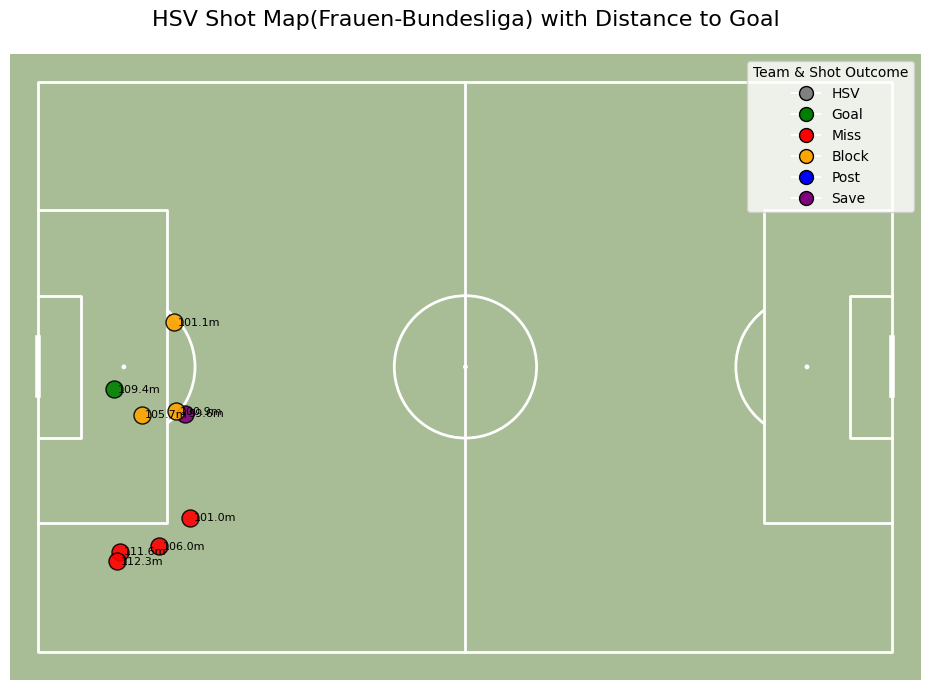

In [69]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Use the same data as before
df = pd.DataFrame({
    "team_home": [False]*27 + [True]*9,
    "player": [
        "Cornelia Kramer","Cornelia Kramer","Cornelia Kramer","Cornelia Kramer","Cornelia Kramer",
        "Julia Mickenhagen","Julia Mickenhagen","Juliette Vidal","Juliette Vidal",
        "Katharina Piljić","Katharina Piljić","Katharina Piljić","Katharina Piljić",
        "Kristin Kögel","Loreen Bender","Loreen Bender","Loreen Bender","Loreen Bender",
        "Ruby Grant","Ruby Grant","Ruby Grant","Sofie Zdebel","Sofie Zdebel",
        "Vanessa Fudalla","Vanessa Fudalla","Vanessa Fudalla","Vanessa Fudalla",
        "Camilla Linberg","Jonna Wrede","Melanie Brunnthaler","Melina Krüger",
        "Mária Mikolajová","Mária Mikolajová","Mária Mikolajová","Pauline Machtens","Svea Stoldt"
    ],
    "x": [
        3.6,7.0,8.6,10.6,12.1,8.1,18.1,4.1,18.9,8.5,12.7,13.7,27.1,3.9,5.8,9.7,10.1,12.2,
        9.7,13.9,20.4,16.2,25.4,9.4,13.4,18.3,25.3,10.6,19.1,14.5,11.5,11.1,17.0,21.3,20.6,19.3
    ],
    "y": [
        50.3,48.5,69.5,58.4,44.3,37.3,45.4,45.2,38.5,43.4,38.5,66.1,42.6,43.8,49.3,51.8,56.0,66.0,
        42.7,40.0,35.4,62.4,49.8,60.3,41.2,52.4,59.8,43.1,33.7,46.7,66.0,67.3,65.2,61.2,46.6,46.2
    ],
    "shot_type": [
        "miss","miss","save","miss","post","goal","block","save","save",
        "goal","miss","miss","save","save","save","miss","miss","miss",
        "save","miss","block","miss","block","goal","block","block","block",
        "goal","block","block","miss","miss","miss","miss","save","block"
    ],
    "count":[1]*36
})

# Filter for HSV shots only
df_hsv = df[df['team_home'] == True]

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Color map for shot outcomes
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'post':'blue', 'save':'purple'}

# Function to calculate distance to goal
def distance_to_goal(x, y):
    return np.round(np.sqrt((120 - x)**2 + (40 - y)**2),1)  # Home attacks right

# Plot HSV shots
for idx, row in df_hsv.iterrows():
    dist = distance_to_goal(row['x'], row['y'])
    ax.scatter(row['x'], row['y'],
               color=shot_colors[row['shot_type']],
               s=150*row['count'],
               edgecolors='black',
               alpha=0.9,
               marker='o',  # HSV is home team → circle
               zorder=5)
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='HSV', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]
shot_elements = [Line2D([0], [0], marker='o', color='w', label=k.capitalize(), markerfacecolor=v, markersize=10, markeredgecolor='black') for k,v in shot_colors.items()]
ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')

ax.set_title("HSV Shot Map(Frauen-Bundesliga) with Distance to Goal", fontsize=16, pad=20)
plt.show()

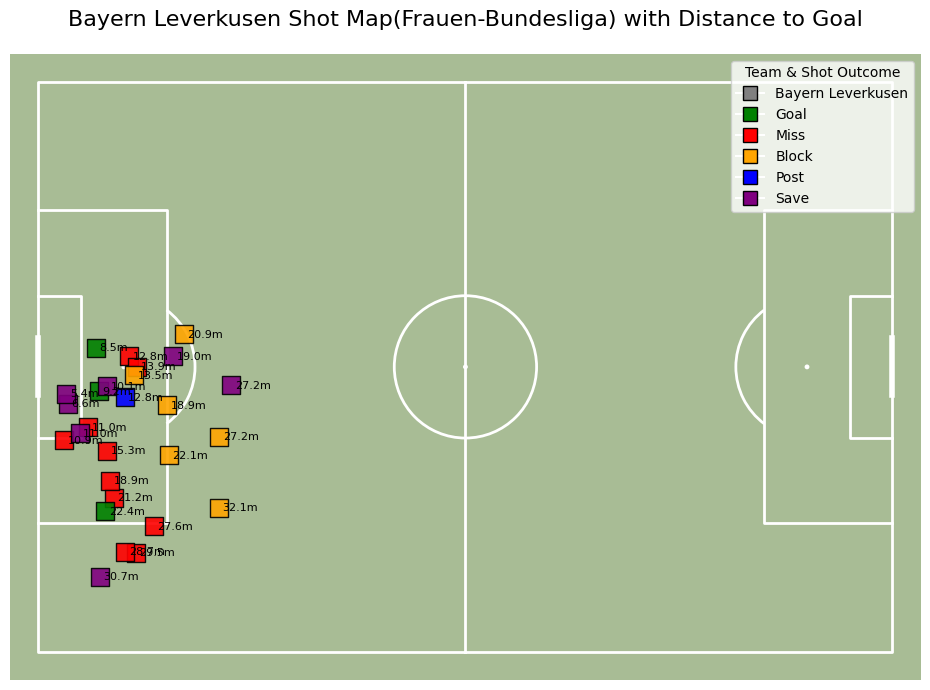

In [71]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Same full match data
df = pd.DataFrame({
    "team_home": [False]*27 + [True]*9,
    "player": [
        "Cornelia Kramer","Cornelia Kramer","Cornelia Kramer","Cornelia Kramer","Cornelia Kramer",
        "Julia Mickenhagen","Julia Mickenhagen","Juliette Vidal","Juliette Vidal",
        "Katharina Piljić","Katharina Piljić","Katharina Piljić","Katharina Piljić",
        "Kristin Kögel","Loreen Bender","Loreen Bender","Loreen Bender","Loreen Bender",
        "Ruby Grant","Ruby Grant","Ruby Grant","Sofie Zdebel","Sofie Zdebel",
        "Vanessa Fudalla","Vanessa Fudalla","Vanessa Fudalla","Vanessa Fudalla",
        "Camilla Linberg","Jonna Wrede","Melanie Brunnthaler","Melina Krüger",
        "Mária Mikolajová","Mária Mikolajová","Mária Mikolajová","Pauline Machtens","Svea Stoldt"
    ],
    "x": [
        3.6,7.0,8.6,10.6,12.1,8.1,18.1,4.1,18.9,8.5,12.7,13.7,27.1,3.9,5.8,9.7,10.1,12.2,
        9.7,13.9,20.4,16.2,25.4,9.4,13.4,18.3,25.3,10.6,19.1,14.5,11.5,11.1,17.0,21.3,20.6,19.3
    ],
    "y": [
        50.3,48.5,69.5,58.4,44.3,37.3,45.4,45.2,38.5,43.4,38.5,66.1,42.6,43.8,49.3,51.8,56.0,66.0,
        42.7,40.0,35.4,62.4,49.8,60.3,41.2,52.4,59.8,43.1,33.7,46.7,66.0,67.3,65.2,61.2,46.6,46.2
    ],
    "shot_type": [
        "miss","miss","save","miss","post","goal","block","save","save",
        "goal","miss","miss","save","save","save","miss","miss","miss",
        "save","miss","block","miss","block","goal","block","block","block",
        "goal","block","block","miss","miss","miss","miss","save","block"
    ],
    "count":[1]*36
})

# Filter for Bayern Leverkusen shots only (away team)
df_bayern = df[df['team_home'] == False]

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Color map for shot outcomes
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'post':'blue', 'save':'purple'}

# Distance to goal for away team (attacks left)
def distance_to_goal_away(x, y):
    return np.round(np.sqrt((0 - x)**2 + (40 - y)**2),1)

# Plot Bayern Leverkusen shots
for idx, row in df_bayern.iterrows():
    dist = distance_to_goal_away(row['x'], row['y'])
    ax.scatter(row['x'], row['y'],
               color=shot_colors[row['shot_type']],
               s=150*row['count'],
               edgecolors='black',
               alpha=0.9,
               marker='s',  # Away → square
               zorder=5)
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Bayern Leverkusen', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]
shot_elements = [Line2D([0], [0], marker='s', color='w', label=k.capitalize(), markerfacecolor=v, markersize=10, markeredgecolor='black') for k,v in shot_colors.items()]
ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')

ax.set_title("Bayern Leverkusen Shot Map(Frauen-Bundesliga) with Distance to Goal", fontsize=16, pad=20)
plt.show()